# A - EfficientNet-B3 PyTorch

PyTorch/timm + CORN ordinal regression baseline. C 모델과 batch, epoch, seed, LR, worker, AMP 정책을 동일하게 맞춘 단일 front 이미지 baseline입니다.

In [1]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("PYTHONHASHSEED", os.environ.get("SEED", "42"))

import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms.functional as TF
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Stop here to avoid accidental CPU training. "
        "Check NVIDIA driver/CUDA state before running this notebook."
    )

device = torch.device("cuda:0")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"timm: {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda:0
PyTorch: 2.8.0+cu128
timm: 1.0.27
CUDA available: True
GPU count: 1
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
class CFG:
    WORKSPACE_ROOT = Path('/workspace')
    MODEL_B_ROOT = WORKSPACE_ROOT / 'mint' / 'model_b'
    PREPROCESSED_DIR = WORKSPACE_ROOT / 'preprocessed_ssim09_blur10_300'
    MANIFESTS_DIR = PREPROCESSED_DIR / 'manifests'
    CHECKPOINT_DIR = MODEL_B_ROOT / 'checkpoints'

    IMG_SIZE      = 300
    NUM_CLASSES   = 5

    MODEL_NAME    = 'B_efficientnet_b3_torch'
    BACKBONE_NAME = 'efficientnet_b3'
    PRETRAINED    = True
    from huggingface_hub import hf_hub_download
    PRETRAINED_WEIGHTS = Path(
        hf_hub_download(
            repo_id="timm/efficientnet_b3.ra2_in1k",
            filename="model.safetensors"
        )
    )
    FEATURE_DIM   = 1536
    DROPOUT       = 0.3

    BATCH_SIZE    = 128
    NUM_WORKERS   = 4
    WARMUP_EPOCHS = 5
    MAX_EPOCHS    = 100
    PATIENCE      = 10
    BACKBONE_LR   = 3e-5
    HEAD_LR       = 3e-4
    WEIGHT_DECAY  = 2e-4
    GRAD_CLIP     = 1.0
    AMP_ENABLED   = os.environ.get('AMP_ENABLED', '1').lower() in {'1', 'true', 'yes', 'on'}
    AMP_DTYPE     = torch.bfloat16
    RUN_INDEX     = int(os.environ.get('RUN_INDEX', 0))
    SEED          = int(os.environ.get('SEED', 42))
    RUN_NAME      = os.environ.get('RUN_NAME', f'run_{RUN_INDEX + 1:02d}_seed_{SEED}')
    RUN_DIR       = CHECKPOINT_DIR / RUN_NAME

    MEAN          = [0.485, 0.456, 0.406]
    STD           = [0.229, 0.224, 0.225]

CFG.CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CFG.RUN_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass

set_seed(CFG.SEED)

print(f"PREPROCESSED_DIR exists: {CFG.PREPROCESSED_DIR.exists()}")
print(f"MANIFESTS_DIR exists:    {CFG.MANIFESTS_DIR.exists()}")
print(f"CHECKPOINT_DIR:          {CFG.CHECKPOINT_DIR}")
print(f"RUN_DIR:                 {CFG.RUN_DIR}")
print(f"RUN_SEED:                {CFG.SEED}")
print(f"BATCH_SIZE:              {CFG.BATCH_SIZE}")
print(f"AMP_ENABLED:             {CFG.AMP_ENABLED}")
print(f"AMP_DTYPE:               {CFG.AMP_DTYPE}")


PREPROCESSED_DIR exists: True
MANIFESTS_DIR exists:    True
CHECKPOINT_DIR:          /workspace/mint/model_b/checkpoints
RUN_DIR:                 /workspace/mint/model_b/checkpoints/run_01_seed_42
RUN_SEED:                42
BATCH_SIZE:              128
AMP_ENABLED:             True
AMP_DTYPE:               torch.bfloat16


In [3]:
def remap_path(orig_path, new_root, marker='preprocessed_ssim09_blur10_300'):
    orig = str(orig_path).replace('/', '\\')
    if marker not in orig:
        return orig
    relative = orig.split(marker, 1)[1].lstrip('\\').lstrip('/')
    relative_parts = [part for part in relative.replace('\\', '/').split('/') if part]
    return str(Path(new_root).joinpath(*relative_parts))


def load_split_from_manifest(manifests_dir, preprocessed_root, verify_files=True):
    splits = {}
    for split_name in ['train', 'val', 'test']:
        csv_path = manifests_dir / f'{split_name}.csv'
        if not csv_path.exists():
            raise FileNotFoundError(f"{csv_path} 가 없습니다.")
        df = pd.read_csv(csv_path)
        print(f"\n[{split_name}] CSV 로드: {len(df)} 행")
        df['front_path'] = df['front_path'].apply(lambda p: remap_path(p, preprocessed_root))
        if verify_files:
            before = len(df)
            df = df[df['front_path'].apply(lambda p: Path(p).exists())].copy()
            after = len(df)
            print(f"  front_path 존재: {after}/{before}")
        before = len(df)
        df = df[df['condition'].isin([1, 2, 3, 4, 5])].copy()
        if len(df) != before:
            print(f"  condition 필터: {before} -> {len(df)}")
        splits[split_name] = df.reset_index(drop=True)
    return splits['train'], splits['val'], splits['test']


df_train, df_val, df_test = load_split_from_manifest(
    CFG.MANIFESTS_DIR,
    CFG.PREPROCESSED_DIR,
    verify_files=True,
)

print("\n=== Final ===")
print(f"Train: {len(df_train)}")
print(f"Val:   {len(df_val)}")
print(f"Test:  {len(df_test)}")
print("\n=== condition 분포 ===")
print("train", df_train['condition'].value_counts().sort_index().to_dict())
print("val  ", df_val['condition'].value_counts().sort_index().to_dict())
print("test ", df_test['condition'].value_counts().sort_index().to_dict())


[train] CSV 로드: 21886 행
  front_path 존재: 21886/21886

[val] CSV 로드: 6253 행
  front_path 존재: 6253/6253

[test] CSV 로드: 3127 행
  front_path 존재: 3127/3127

=== Final ===
Train: 21886
Val:   6253
Test:  3127

=== condition 분포 ===
train {1: 730, 2: 3447, 3: 6721, 4: 5332, 5: 5656}
val   {1: 209, 2: 985, 3: 1920, 4: 1523, 5: 1616}
test  {1: 104, 2: 493, 3: 960, 4: 762, 5: 808}


In [4]:
class GarmentFrontDataset(Dataset):
    """front_path 단일 이미지 + condition ordinal label."""

    def __init__(self, df, img_size=300, mode='train'):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.mode = mode
        self.normalize = T.Normalize(mean=CFG.MEAN, std=CFG.STD)
        # 증강 강화: 일부 영역을 가려 과적합 억제 (train 전용)
        self.random_erase = T.RandomErasing(p=0.25, scale=(0.02, 0.12), value=0.0)

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if img.size != (self.img_size, self.img_size):
            img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        return img

    def _train_transform(self, img):
        # RandomResizedCrop 추가 (과적합 완화)
        ci, cj, ch, cw = T.RandomResizedCrop.get_params(
            img, scale=(0.75, 1.0), ratio=(0.9, 1.1)
        )
        img = TF.resized_crop(img, ci, cj, ch, cw, [self.img_size, self.img_size])
        if random.random() < 0.5:
            img = TF.hflip(img)
        angle = random.uniform(-10, 10)
        img = TF.rotate(img, angle, fill=255)
        img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
        img = TF.adjust_contrast(img, random.uniform(0.8, 1.2))
        img = TF.adjust_saturation(img, random.uniform(0.85, 1.15))
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load(row['front_path'])
        if self.mode == 'train':
            img = self._train_transform(img)
        img = self.normalize(TF.to_tensor(img))
        if self.mode == 'train':
            img = self.random_erase(img)
        target = int(row['condition']) - 1
        return img, target


train_ds = GarmentFrontDataset(df_train, CFG.IMG_SIZE, mode='train')
val_ds   = GarmentFrontDataset(df_val,   CFG.IMG_SIZE, mode='val')
test_ds  = GarmentFrontDataset(df_test,  CFG.IMG_SIZE, mode='val')

img, target = train_ds[0]
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"sample image: {img.shape}, dtype={img.dtype}")
print(f"target (0~4): {target} -> condition={target+1}")

Train: 21886 | Val: 6253 | Test: 3127
sample image: torch.Size([3, 300, 300]), dtype=torch.float32
target (0~4): 3 -> condition=4


In [5]:
class SingleViewModel(nn.Module):
    """timm backbone + MLP head for 5-class classification."""

    def __init__(self, backbone_name, feature_dim, pretrained=True, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=False,
            num_classes=0,
            global_pool='',
        )
        if pretrained:
            if not CFG.PRETRAINED_WEIGHTS.exists():
                raise FileNotFoundError(f'Pretrained weights not found: {CFG.PRETRAINED_WEIGHTS}')
            from safetensors.torch import load_file
            state_dict = load_file(str(CFG.PRETRAINED_WEIGHTS), device='cpu')
            self.backbone.load_state_dict(state_dict, strict=False)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def extract_features(self, x):
        feat = self.backbone(x)
        feat = self.gap(feat)
        return feat.flatten(1)

    def forward(self, x):
        feat = self.extract_features(x)
        return self.head(feat)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


model = SingleViewModel(
    backbone_name=CFG.BACKBONE_NAME,
    pretrained=CFG.PRETRAINED,
    feature_dim=CFG.FEATURE_DIM,
    num_classes=CFG.NUM_CLASSES,
    dropout=CFG.DROPOUT,
).to(device)

model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(device)
    out = model(dummy)
model.train()
    print(f"Output shape: {out.shape} (expected [2, 5])")

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}")
print(f"Trainable: {trainable:,}")


Output shape: torch.Size([2, 5]) (expected [2, 5])
Total params: 11,485,741
Trainable: 11,485,741


In [6]:
def predict(logits):
    return logits.argmax(dim=1)


def compute_metrics(preds, targets):
    preds   = np.asarray(preds,   dtype=np.int64)
    targets = np.asarray(targets, dtype=np.int64)
    return {
        'acc':          float(accuracy_score(targets, preds)),
        'balanced_acc': float(balanced_accuracy_score(targets, preds)),
        'f1_weighted':  float(f1_score(targets, preds, average='weighted', zero_division=0)),
        'f1_macro':     float(f1_score(targets, preds, average='macro',    zero_division=0)),
        'kappa':        float(cohen_kappa_score(targets, preds)),
    }

# 클래스 불균형 대응: train 분포로 class weight 계산 (balanced / inverse-frequency)
_class_counts = df_train['condition'].astype(int).value_counts().sort_index()
_counts = np.array([_class_counts.get(c, 0) for c in range(1, CFG.NUM_CLASSES + 1)], dtype=np.float64)
_class_weights = _counts.sum() / (CFG.NUM_CLASSES * np.clip(_counts, 1, None))
_class_weights = torch.tensor(_class_weights, dtype=torch.float32, device=device)
print(f"class counts:  {_counts.astype(int).tolist()}")
print(f"class weights: {_class_weights.cpu().numpy().round(3).tolist()}")

# weighted CE + 약한 label smoothing (소수 클래스 학습 + 과적합 완화)
criterion = nn.CrossEntropyLoss(weight=_class_weights, label_smoothing=0.05)

# smoke test
fake_logits = torch.randn(4, 5)
fake_target = torch.tensor([0, 2, 4, 1])
loss = criterion(fake_logits.to(device), fake_target.to(device))
preds_smoke = predict(fake_logits)
print(f"loss smoke: {loss.item():.4f}")
print(f"pred smoke: {preds_smoke.tolist()}")
print(f"metric smoke: {compute_metrics(preds_smoke, fake_target)}")


class counts:  [730, 3447, 6721, 5332, 5656]
class weights: [5.995999813079834, 1.2699999809265137, 0.6510000228881836, 0.8209999799728394, 0.7739999890327454]
loss smoke: 2.9932
pred smoke: [3, 4, 4, 1]
metric smoke: {'acc': 0.5, 'balanced_acc': 0.5, 'f1_weighted': 0.41666666666666663, 'f1_macro': 0.3333333333333333, 'kappa': 0.3846153846153846}


In [7]:
def train_one_epoch(model, loader, optimizer, epoch_idx):
    model.train()
    total_loss = 0.0
    n_samples = 0
    all_preds, all_targets = [], []
    pbar = tqdm(loader, desc=f"Epoch {epoch_idx} [train]", leave=False)
    for images, target in pbar:
        images = images.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.AMP_ENABLED, dtype=CFG.AMP_DTYPE):
            logits = model(images)
            loss = criterion(logits, target)
        if not torch.isfinite(loss):
            print("Non-finite train loss detected")
            print("target min/max:", target.min().item(), target.max().item())
            print("logits min/max:", logits.detach().min().item(), logits.detach().max().item())
            raise RuntimeError("NaN/Inf train loss")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.GRAD_CLIP)
        optimizer.step()
        with torch.no_grad():
            preds = predict(logits)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())
        total_loss += loss.item() * images.size(0)
        n_samples += target.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    metrics = compute_metrics(np.concatenate(all_preds), np.concatenate(all_targets))
    metrics['loss'] = total_loss / n_samples
    return metrics


@torch.no_grad()
def evaluate(model, loader, desc='val'):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    all_preds, all_targets = [], []
    for images, target in tqdm(loader, desc=f"[{desc}]", leave=False):
        images = images.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        with autocast(enabled=CFG.AMP_ENABLED, dtype=CFG.AMP_DTYPE):
            logits = model(images)
            loss = criterion(logits, target)
        if not torch.isfinite(loss):
            print("Non-finite validation loss detected")
            print("target min/max:", target.min().item(), target.max().item())
            print("logits min/max:", logits.detach().min().item(), logits.detach().max().item())
            raise RuntimeError("NaN/Inf validation loss")
        preds = predict(logits)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(target.cpu().numpy())
        total_loss += loss.item() * images.size(0)
        n_samples += target.size(0)
    metrics = compute_metrics(np.concatenate(all_preds), np.concatenate(all_targets))
    metrics['loss'] = total_loss / n_samples
    return metrics, np.concatenate(all_preds), np.concatenate(all_targets)


In [8]:
def seed_worker(worker_id):
    worker_seed = CFG.SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(CFG.SEED)

train_loader = DataLoader(
    train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=(CFG.NUM_WORKERS > 0),
    worker_init_fn=seed_worker, generator=loader_generator,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True,
    persistent_workers=(CFG.NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
)
test_loader = DataLoader(
    test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True,
    persistent_workers=(CFG.NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
)


optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG.BACKBONE_LR},
    {'params': model.head.parameters(), 'lr': CFG.HEAD_LR},
], weight_decay=CFG.WEIGHT_DECAY)

# LR이 거의 안 떨어지던 문제 수정: val_loss plateau에 반응해 lr을 절반씩 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6,
)


print(f"학습 준비 완료 (model={CFG.MODEL_NAME}, device={device})")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")


학습 준비 완료 (model=B_efficientnet_b3_torch, device=cuda:0)
Train batches: 170
Val batches:   49


In [9]:
history = {'train': [], 'val': []}
best_val_loss = float('inf')
patience_counter = 0
best_epoch = -1
best_path = CFG.RUN_DIR / f'best_{CFG.MODEL_NAME}.pt'

def _save_best(epoch, val_m):
    global best_val_loss, best_epoch, patience_counter
    if np.isfinite(val_m['loss']) and val_m['loss'] < best_val_loss:
        best_val_loss, best_epoch, patience_counter = val_m['loss'], epoch, 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'val_metrics': val_m,
                    'config': {k: str(v) for k, v in vars(CFG).items() if not k.startswith('_')}},
                   best_path)
        print(f'  Best updated (Loss {best_val_loss:.4f})')
    else:
        patience_counter += 1
        if not np.isfinite(val_m['loss']):
            print('  Skipped checkpoint: non-finite validation metric')

print('=' * 60)
print(f'Stage 1: Warmup - {CFG.MODEL_NAME} backbone freeze, head only')
print('=' * 60)
model.freeze_backbone()

for epoch in range(CFG.WARMUP_EPOCHS):
    train_m = train_one_epoch(model, train_loader, optimizer, epoch)
    val_m, _, _ = evaluate(model, val_loader, desc='val')
    history['train'].append({'epoch': epoch, **train_m})
    history['val'].append({'epoch': epoch, **val_m})
    print(f'[Warmup {epoch+1}/{CFG.WARMUP_EPOCHS}] '
          f'train_loss={train_m["loss"]:.4f} acc={train_m["acc"]:.3f} | '
          f'val_loss={val_m["loss"]:.4f} acc={val_m["acc"]:.3f} f1={val_m["f1_weighted"]:.3f}')
    _save_best(epoch, val_m)

print('\n' + '=' * 60)
print(f'Stage 2: Full fine-tuning - {CFG.MODEL_NAME} backbone unfreeze')
print('=' * 60)
model.unfreeze_backbone()
patience_counter = 0

for epoch in range(CFG.WARMUP_EPOCHS, CFG.MAX_EPOCHS):
    train_m = train_one_epoch(model, train_loader, optimizer, epoch)
    val_m, _, _ = evaluate(model, val_loader, desc='val')
    scheduler.step(val_m['loss'])
    history['train'].append({'epoch': epoch, **train_m})
    history['val'].append({'epoch': epoch, **val_m})
    cur_lr_b = optimizer.param_groups[0]['lr']
    cur_lr_h = optimizer.param_groups[1]['lr']
    print(f'[Epoch {epoch+1}/{CFG.MAX_EPOCHS}] '
          f'train_loss={train_m["loss"]:.4f} acc={train_m["acc"]:.3f} | '
          f'val_loss={val_m["loss"]:.4f} acc={val_m["acc"]:.3f} '
          f'f1={val_m["f1_weighted"]:.3f} kappa={val_m["kappa"]:.3f} | '
          f'lr_b={cur_lr_b:.2e} lr_h={cur_lr_h:.2e}')
    _save_best(epoch, val_m)
    if patience_counter >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {CFG.PATIENCE} epochs)')
        break

print(f'\n학습 완료. Best epoch: {best_epoch+1}, Best val Loss: {best_val_loss:.4f}')
print(f'Best checkpoint: {best_path}')


Stage 1: Warmup — B_efficientnet_b3_torch backbone freeze, head only


Epoch 0 [train]:   0%|          | 0/170 [00:00<?, ?it/s]

[val]:   0%|          | 0/49 [00:00<?, ?it/s]

[Warmup 1/5] train_loss=1.6408 acc=0.204 | val_loss=1.7267 acc=0.237 f1=0.247
  Best updated (Loss 1.7267)


Epoch 1 [train]:   0%|          | 0/170 [00:00<?, ?it/s]

...

[val]:   0%|          | 0/49 [00:00<?, ?it/s]

[Epoch 16/100] train_loss=1.2791 acc=0.457 | val_loss=1.9888 acc=0.323 f1=0.328 kappa=0.141 | lr_b=3.75e-06 lr_h=3.75e-05


Epoch 16 [train]:   0%|          | 0/170 [00:00<?, ?it/s]

[val]:   0%|          | 0/49 [00:00<?, ?it/s]

[Epoch 17/100] train_loss=1.2594 acc=0.468 | val_loss=1.7219 acc=0.329 f1=0.335 kappa=0.143 | lr_b=3.75e-06 lr_h=3.75e-05

Early stopping at epoch 17 (no improvement for 10 epochs)

학습 완료. Best epoch: 7, Best val Loss: 1.6083
Best checkpoint: /workspace/mint/model_b/checkpoints/run_01_seed_42/best_B_efficientnet_b3_torch.pt


In [11]:
best_path = CFG.RUN_DIR / f'best_{CFG.MODEL_NAME}.pt'
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']+1}")
print(f"Saved val metrics: {ckpt['val_metrics']}")

test_metrics, test_preds, test_targets = evaluate(model, test_loader, desc='test')

print("\n=== Test Metrics ===")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

pd.DataFrame(history['train']).to_csv(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_history_train.csv', index=False)
pd.DataFrame(history['val']).to_csv(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_history_val.csv', index=False)

cm = confusion_matrix(test_targets, test_preds, labels=[0, 1, 2, 3, 4])
pd.DataFrame(cm, index=[1,2,3,4,5], columns=[1,2,3,4,5]).to_csv(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_confusion.csv')

result = {
    'model': CFG.MODEL_NAME,
    'backbone': CFG.BACKBONE_NAME,
    'run_name': CFG.RUN_NAME,
    'seed': int(CFG.SEED),
    'best_epoch': int(ckpt['epoch']),
    'val_metrics': {k: float(v) for k, v in ckpt['val_metrics'].items()},
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'data': {
        'n_train': len(df_train),
        'n_val': len(df_val),
        'n_test': len(df_test),
    },
    'env': {
        'torch': torch.__version__,
        'timm': timm.__version__,
        'gpu': torch.cuda.get_device_name(0),
    },
    'config': {k: str(v) for k, v in vars(CFG).items() if not k.startswith('_')},
}
with open(CFG.RUN_DIR / f'{CFG.MODEL_NAME}_result.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

print("결과 저장 완료:", CFG.RUN_DIR)


Loaded best checkpoint from epoch 7
Saved val metrics: {'acc': 0.30513353590276665, 'balanced_acc': 0.32274718276632547, 'f1_weighted': 0.2995042854213134, 'f1_macro': 0.27241182285702426, 'kappa': 0.13745850874175636, 'loss': 1.608301527153563}


[test]:   0%|          | 0/25 [00:00<?, ?it/s]


=== Test Metrics ===
  acc: 0.3102
  balanced_acc: 0.3278
  f1_weighted: 0.3025
  f1_macro: 0.2752
  kappa: 0.1427
  loss: 1.6089
결과 저장 완료: /workspace/mint/model_b/checkpoints/run_01_seed_42


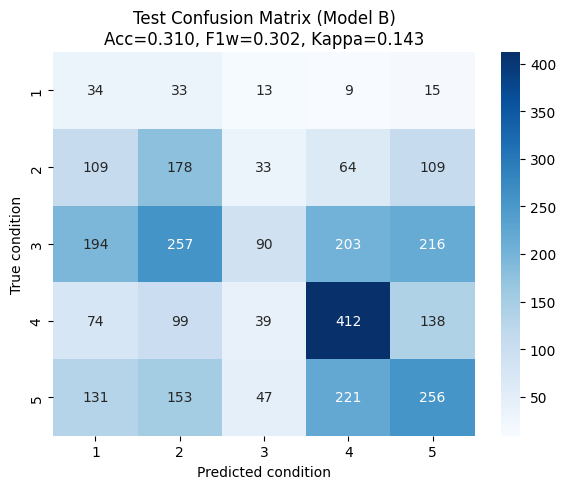

In [12]:
# Confusion Matrix
cm = confusion_matrix(test_targets, test_preds, labels=[0,1,2,3,4])
class_names = ['1', '2', '3', '4', '5']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted condition')
plt.ylabel('True condition')
plt.title(f'Test Confusion Matrix (Model B)\n'
          f'Acc={test_metrics["acc"]:.3f}, F1w={test_metrics["f1_weighted"]:.3f}, '
          f'Kappa={test_metrics["kappa"]:.3f}')
plt.tight_layout()
plt.show()
